In [1]:
# Importing the necessary libraries.

import pandas as pd,numpy as np, matplotlib.pyplot as plt , seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
import warnings
warnings.filterwarnings('ignore')

## Importing Data

In [2]:
data = pd.read_excel('data/data.xlsx').sort_values('Date',ascending = True)
data.rename(columns = lambda x: x.lower(), inplace = True)
data.set_index('date').head()

,carbon_futures_price,dow_jones,crude_oil_futures,natural_gas_contract,gdp,per_capita_carbon_emission,manufacturing,crude_processing,petroleum_and_coal_products,chemical,plastics_and_rubber_products
date,,,,,,,,,,,
2005-06-01,25.80,10274.97,56.50,6.981,12922.7,20.658026,102.0272,85.5464,95.6659,119.3235,108.5847
2005-07-01,22.35,10640.91,60.57,7.885,NaN,NaN,101.6681,85.5714,93.4272,119.7626,108.2360
2005-08-01,23.95,10481.60,68.94,11.472,NaN,NaN,102.2126,84.6292,92.4520,117.6605,109.7142
2005-09-01,22.85,10568.70,66.24,13.921,13142.6,NaN,101.0830,75.2859,87.1851,110.4729,111.5862
2005-10-01,21.90,10440.07,59.76,12.205,NaN,NaN,102.5411,77.6876,85.8411,111.4863,111.6456


In [3]:
# Finding the shape (no of rows and columns) of the data.
data.shape

(223, 12)

## Finding empty Cells

In [4]:
# checking for empty values in the data.

nan = data.isna().sum()
nan = nan[nan.values >0]
nan

gdp                           149
per_capita_carbon_emission    204
dtype: int64

In [5]:
# interpolating the empty values.

data.interpolate('ffill',axis = 0,inplace = True)
print('no of empty cells after interpolation:', data.isnull().any().sum())

no of empty cells after interpolation: 0


## Descriptive Statistics

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
carbon_futures_price,223.0,22.759507,24.585992,0.010000,6.740000,14.250000,25.60500,95.880000
dow_jones,223.0,19125.759372,8404.375479,7062.930000,12224.135000,16580.840000,25864.44000,37689.540000
crude_oil_futures,223.0,72.415740,21.721561,18.840000,54.405000,70.610000,90.97500,140.000000
natural_gas_contract,223.0,4.411915,2.381960,1.640000,2.778000,3.653000,5.08800,13.921000
gdp,223.0,18349.780717,3926.152964,12922.700000,14865.700000,17804.200000,20917.90000,27610.100000
per_capita_carbon_emission,223.0,17.013616,1.832459,14.034053,15.739861,16.876879,17.76503,20.658026
manufacturing,223.0,99.063931,4.618765,79.760700,97.905750,99.541500,100.88150,108.398300
crude_processing,223.0,97.749218,10.481703,75.285900,88.156550,98.610800,106.61115,115.037200
petroleum_and_coal_products,223.0,92.966858,5.618768,69.413600,90.734450,92.803200,96.29215,102.856900
chemical,223.0,105.685991,8.214284,89.892600,100.899950,103.010400,108.64185,126.853600


## Correlation

In [7]:
pd.DataFrame(data.corr(numeric_only = True).carbon_futures_price)

,carbon_futures_price
carbon_futures_price,1.000000
dow_jones,0.758423
crude_oil_futures,0.142004
natural_gas_contract,0.047500
gdp,0.778307
per_capita_carbon_emission,-0.459315
manufacturing,-0.035272
crude_processing,0.405065
petroleum_and_coal_products,-0.288244
chemical,-0.211912


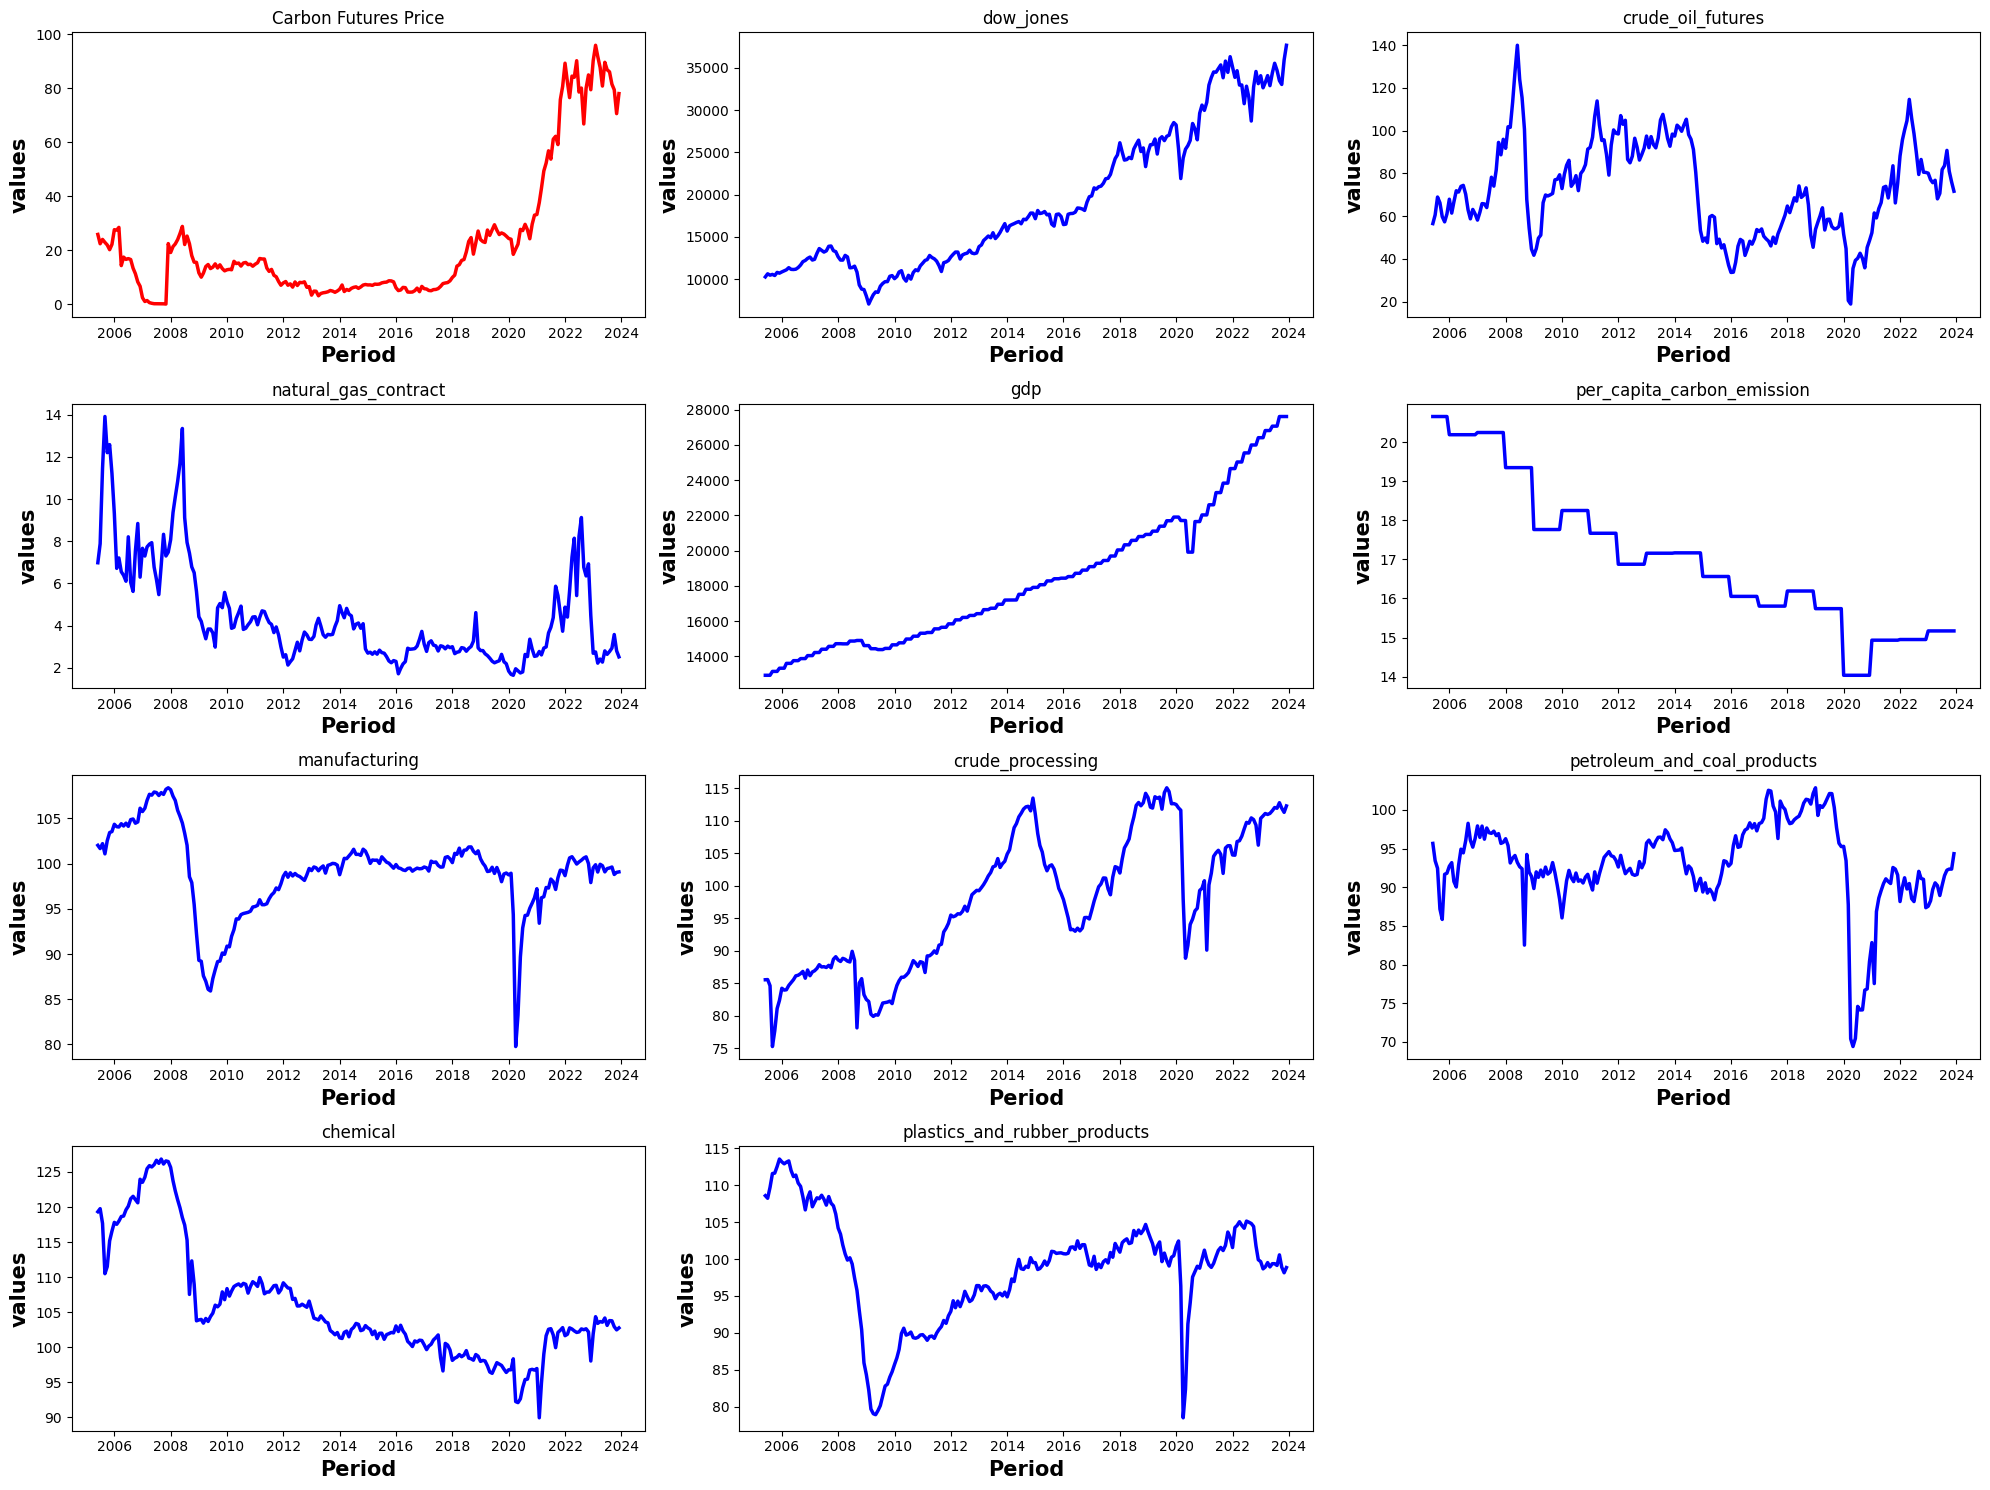

In [8]:
# Plotting the trends of each variable.

plt.figure(figsize=(20, 15))

plt.subplot(4, 3, 1)
plt.plot(data.date, data['carbon_futures_price'], color='red', linewidth=2.5)
plt.xlabel('Period', fontweight='bold', size=15)
plt.ylabel('values', fontweight='bold', size=15)
plt.title('Carbon Futures Price')

plot_number = 2
for column in data.columns[2:]:
    plt.subplot(4, 3, plot_number)
    plt.plot(data.date,data[column], color='blue', linewidth=2.5)
    plt.xlabel('Period', fontweight='bold', size=15)
    plt.ylabel('values', fontweight='bold', size=15)
    plt.title(column)
    plot_number += 1

plt.tight_layout()
plt.show()

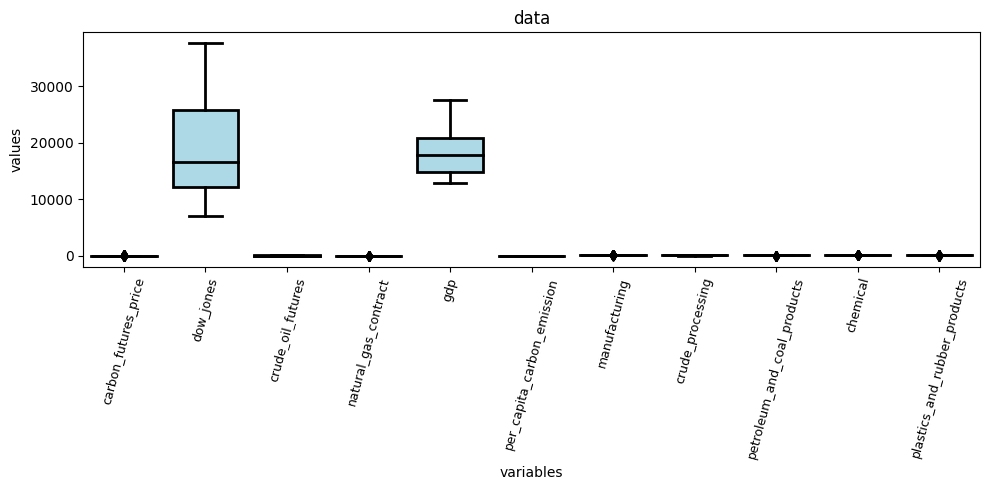

In [9]:
# Checking for outliers.

fig , ax = plt.subplots(figsize = (10,5))
sns.boxplot(data,color='black',linewidth= 2.0,saturation=1, boxprops=dict(facecolor='lightblue'))
plt.title('data')
plt.xticks(rotation = 75, size = 9)
plt.xlabel('variables')
plt.ylabel('values')
plt.tight_layout()
plt.show()

## ARIMA

In [10]:
time_series = data['carbon_futures_price']

def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print(' ')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')
    if result[1] <= 0.05:
        print(' ')
        print("The time series is stationary.")
    else:
        print(' ')
        print("The time series is non-stationary.")

### Dickey Fuller Test - Unit Root Test

In [11]:
check_stationarity(time_series)

ADF Statistic: 0.2675423531495203
p-value: 0.9758053498245807
 
Critical Values:
   1%: -3.4602906385073884
   5%: -2.874708679520702
   10%: -2.573788599127782
 
The time series is non-stationary.


In [12]:
differenced_series = time_series.diff().dropna()

In [13]:
check_stationarity(differenced_series)

ADF Statistic: -16.984005877475663
p-value: 8.969188895777862e-30
 
Critical Values:
   1%: -3.4602906385073884
   5%: -2.874708679520702
   10%: -2.573788599127782
 
The time series is stationary.


### AIC Test

Tested ARIMA(0, 1, 0) - AIC: 1220.321667261503
Tested ARIMA(0, 1, 1) - AIC: 1218.6131359748888
Tested ARIMA(0, 1, 2) - AIC: 1219.4863465476535
Tested ARIMA(0, 1, 3) - AIC: 1220.8601782666806
Tested ARIMA(0, 1, 4) - AIC: 1221.0804291515851
Tested ARIMA(1, 1, 0) - AIC: 1218.0701459600823
Tested ARIMA(1, 1, 1) - AIC: 1218.9491046932349
Tested ARIMA(1, 1, 2) - AIC: 1220.817020038106
Tested ARIMA(1, 1, 3) - AIC: 1221.7668593106464
Tested ARIMA(1, 1, 4) - AIC: 1218.9855630571533
Tested ARIMA(2, 1, 0) - AIC: 1219.0215953569063
Tested ARIMA(2, 1, 1) - AIC: 1220.842193200638
Tested ARIMA(2, 1, 2) - AIC: 1221.5687865618634
Tested ARIMA(2, 1, 3) - AIC: 1223.3832229555792
Tested ARIMA(2, 1, 4) - AIC: 1219.4083853961456
Tested ARIMA(3, 1, 0) - AIC: 1220.795154418359
Tested ARIMA(3, 1, 1) - AIC: 1222.765101108996
Tested ARIMA(3, 1, 2) - AIC: 1219.2733739964442
Tested ARIMA(3, 1, 3) - AIC: 1221.5018505732637
Tested ARIMA(3, 1, 4) - AIC: 1221.2752464932728
Tested ARIMA(4, 1, 0) - AIC: 1222.49374460491

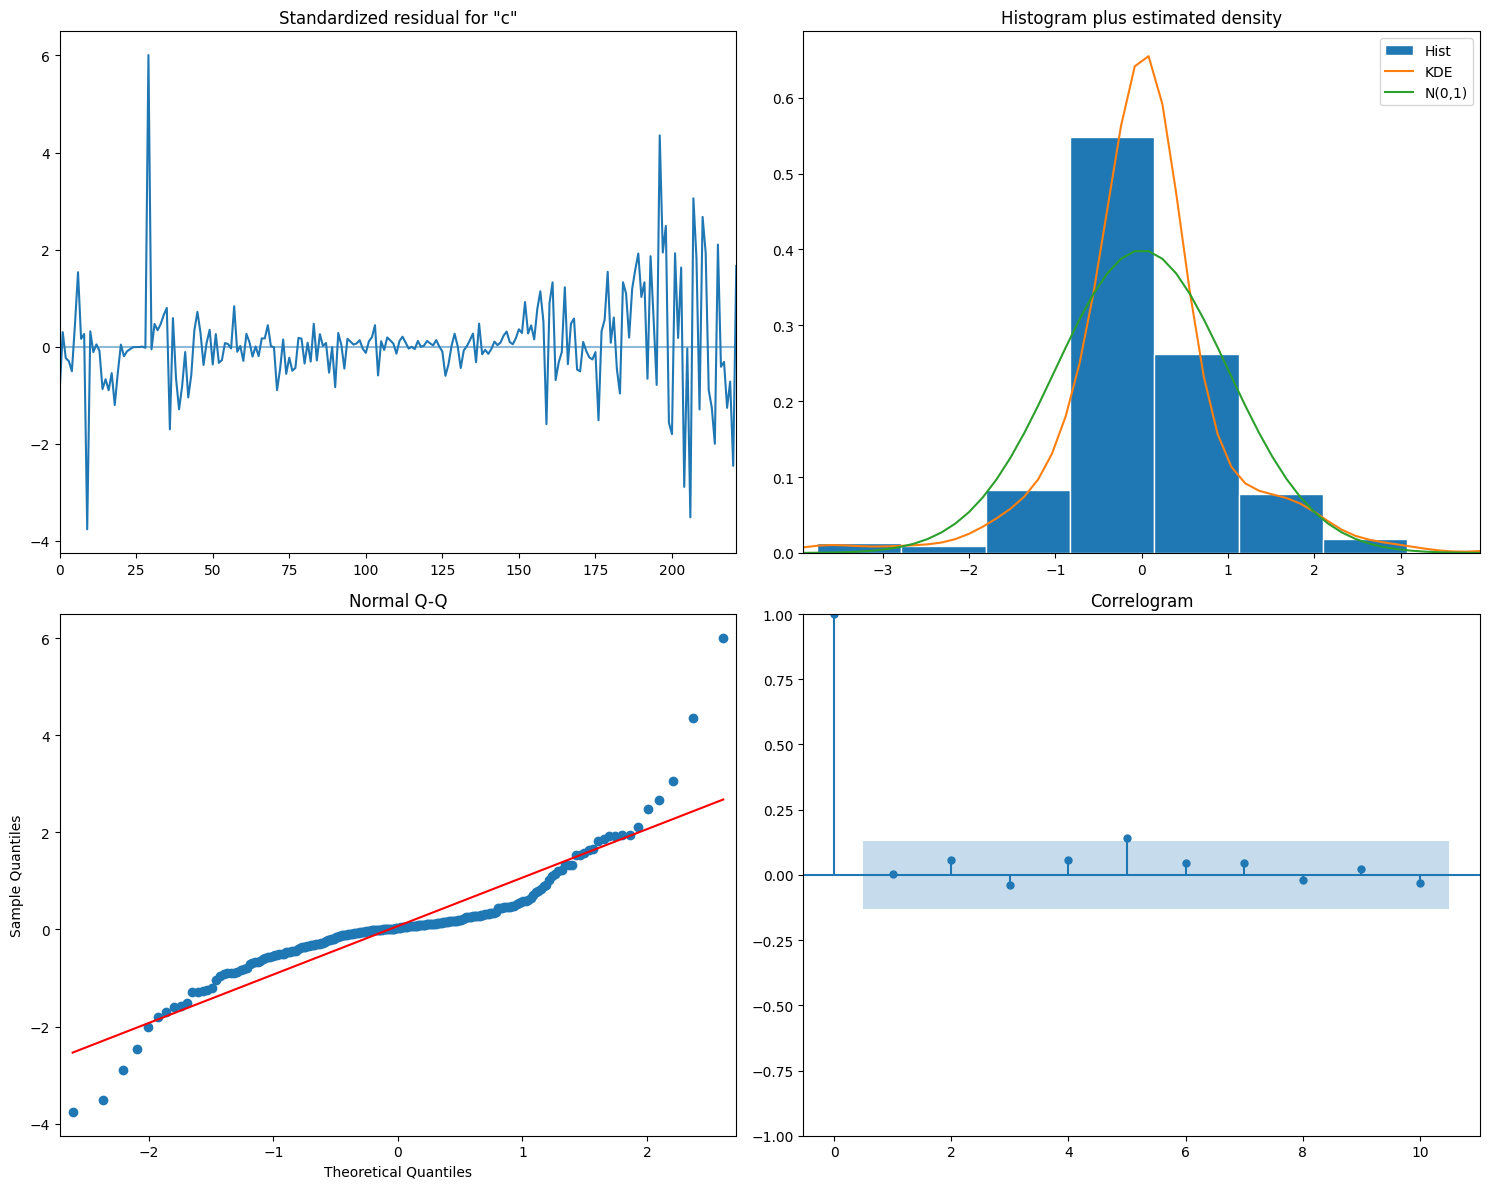

In [14]:
def grid_search_arima(data, p_values, q_values, d=1):
    best_aic = np.inf
    best_order = None
    best_model = None
    for p in p_values:
        for q in q_values:
            try:
                model = sm.tsa.ARIMA(data, order=(p, d, q))
                results = model.fit()
                print(f'Tested ARIMA({p}, {d}, {q}) - AIC: {results.aic}')  
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = (p, d, q)
                    best_model = results
            except Exception as e:
                print(f'Error fitting ARIMA({p}, {d}, {q}): {e}')  
    return best_order, best_model

p_values = range(0, 5)
q_values = range(0, 5)
d = 1  

best_order, best_model = grid_search_arima(data['carbon_futures_price'], p_values, q_values, d)

if best_model is not None:
    print(f'Best order: {best_order}')
    print(' ')
    print(f'Best AIC: {best_model.aic}')

    best_model.plot_diagnostics(figsize=(15, 12))
    plt.tight_layout()
    plt.show()
else:
    print('No suitable ARIMA model found.')

In [15]:
p, d, q = (1, 1, 0)
model = ARIMA(time_series, order=(p, d, q))
results = model.fit()

In [16]:
# output

y_preda = results.predict()
r2 = r2_score(time_series,y_preda)
mse = mean_squared_error(time_series,y_preda)
arima_result = ({'Model':'ARIMA', 'R2 Score':r2, 'Mean Squared Error':mse})
arima_result

{'Model': 'ARIMA',
 'R2 Score': 0.9720672149185204,
 'Mean Squared Error': 16.808843027608823}

In [17]:
# creating a dataframe to save the output.

y_pred_arima = np.array(y_preda)
y_test = np.array(time_series)

arima_pred = pd.DataFrame({"arima_y_pred": y_pred_arima,"carbon_futures_price": y_test})

data_subset = data[['carbon_futures_price', 'date']]

merged_df_arima = pd.merge(arima_pred, data_subset, on='carbon_futures_price', how='inner')
merged_df_arima = merged_df_arima.sort_values('date', ascending=True)

## Feature Engineering

In [18]:
X = data.drop(['date','carbon_futures_price'], axis=1)
y = data['carbon_futures_price']

In [19]:
# Splitting the data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

## Machine Learning Models

In [20]:
# Random Forest Model

rf_model = RandomForestRegressor(max_depth=10, max_features='log2', min_samples_leaf=1, min_samples_split=5, n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
r2_rf=r2_score(y_test,y_pred_rf)
mserf = mean_squared_error(y_test,y_pred_rf)
r2_rf

0.9808840410600561

In [21]:
# saving the output

y_pred_rf = np.array(y_pred_rf)
y_test = np.array(y_test)
rf_pred = pd.DataFrame({
    "rf_y_pred": y_pred_rf,
    "carbon_futures_price": y_test
})
merged_df_rf = pd.merge(rf_pred, data_subset, on='carbon_futures_price', how='inner')
merged_df_rf= merged_df_rf.sort_values('date', ascending=True)

In [22]:
# K Nearest Neighbor Model

knn_model = KNeighborsRegressor(n_neighbors=8)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

r2_knn=r2_score(y_test,y_pred_knn)
mseknn = mean_squared_error(y_test,y_pred_knn)
r2_knn

0.9603606357948762

In [23]:
# Saving the output

y_pred_knn = np.array(y_pred_knn)
y_test = np.array(y_test)
knn_pred = pd.DataFrame({
    "knn_y_pred": y_pred_knn,
    "carbon_futures_price": y_test})

merged_df_knn = pd.merge(knn_pred, data_subset, on='carbon_futures_price', how='inner')
merged_df_knn= merged_df_knn.sort_values('date', ascending=True)

In [24]:
# Gradient Boosting Model
gb_model = GradientBoostingRegressor(n_estimators=50)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

r2_gb=r2_score(y_test,y_pred_gb)
msegb = mean_squared_error(y_test,y_pred_gb)
r2_gb

0.9661207703248914

In [25]:
# Saving the output
y_pred_gb = np.array(y_pred_gb)
y_test = np.array(y_test)
gb_pred = pd.DataFrame({
    "gb_y_pred": y_pred_gb,
    "carbon_futures_price": y_test})

merged_df_gb = pd.merge(gb_pred, data_subset, on='carbon_futures_price', how='inner')
merged_df_gb= merged_df_gb.sort_values('date', ascending=True)

In [26]:
# Decision Tree Model
dt_model = DecisionTreeRegressor(criterion='absolute_error')
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

r2_dt=r2_score(y_test,y_pred_dt)
msedt = mean_squared_error(y_test,y_pred_dt)
r2_dt

0.9182175004796019

In [27]:
# Saving the output

y_pred_dt = np.array(y_pred_dt)
y_test = np.array(y_test)
dt_pred = pd.DataFrame({
    "dt_y_pred": y_pred_dt,
    "carbon_futures_price": y_test})

merged_df_dt = pd.merge(dt_pred, data_subset, on='carbon_futures_price', how='inner')
merged_df_dt= merged_df_dt.sort_values('date', ascending=True)

In [28]:
# Compiling the results
results = pd.DataFrame({'Models':["ARIMA","Random Forest", "Knn","Gradient Boost","Decision Tree"],
                        "R2 Score":[r2,r2_rf,r2_knn,r2_gb,r2_dt],
                        "MSE":[mse,mserf,mseknn,msegb,msedt]}).set_index("Models").sort_values("R2 Score",
                                                                                               ascending=False).round(2)
results

,R2 Score,MSE
Models,,
Random Forest,0.98,9.61
ARIMA,0.97,16.81
Gradient Boost,0.97,17.04
Knn,0.96,19.94
Decision Tree,0.92,41.13


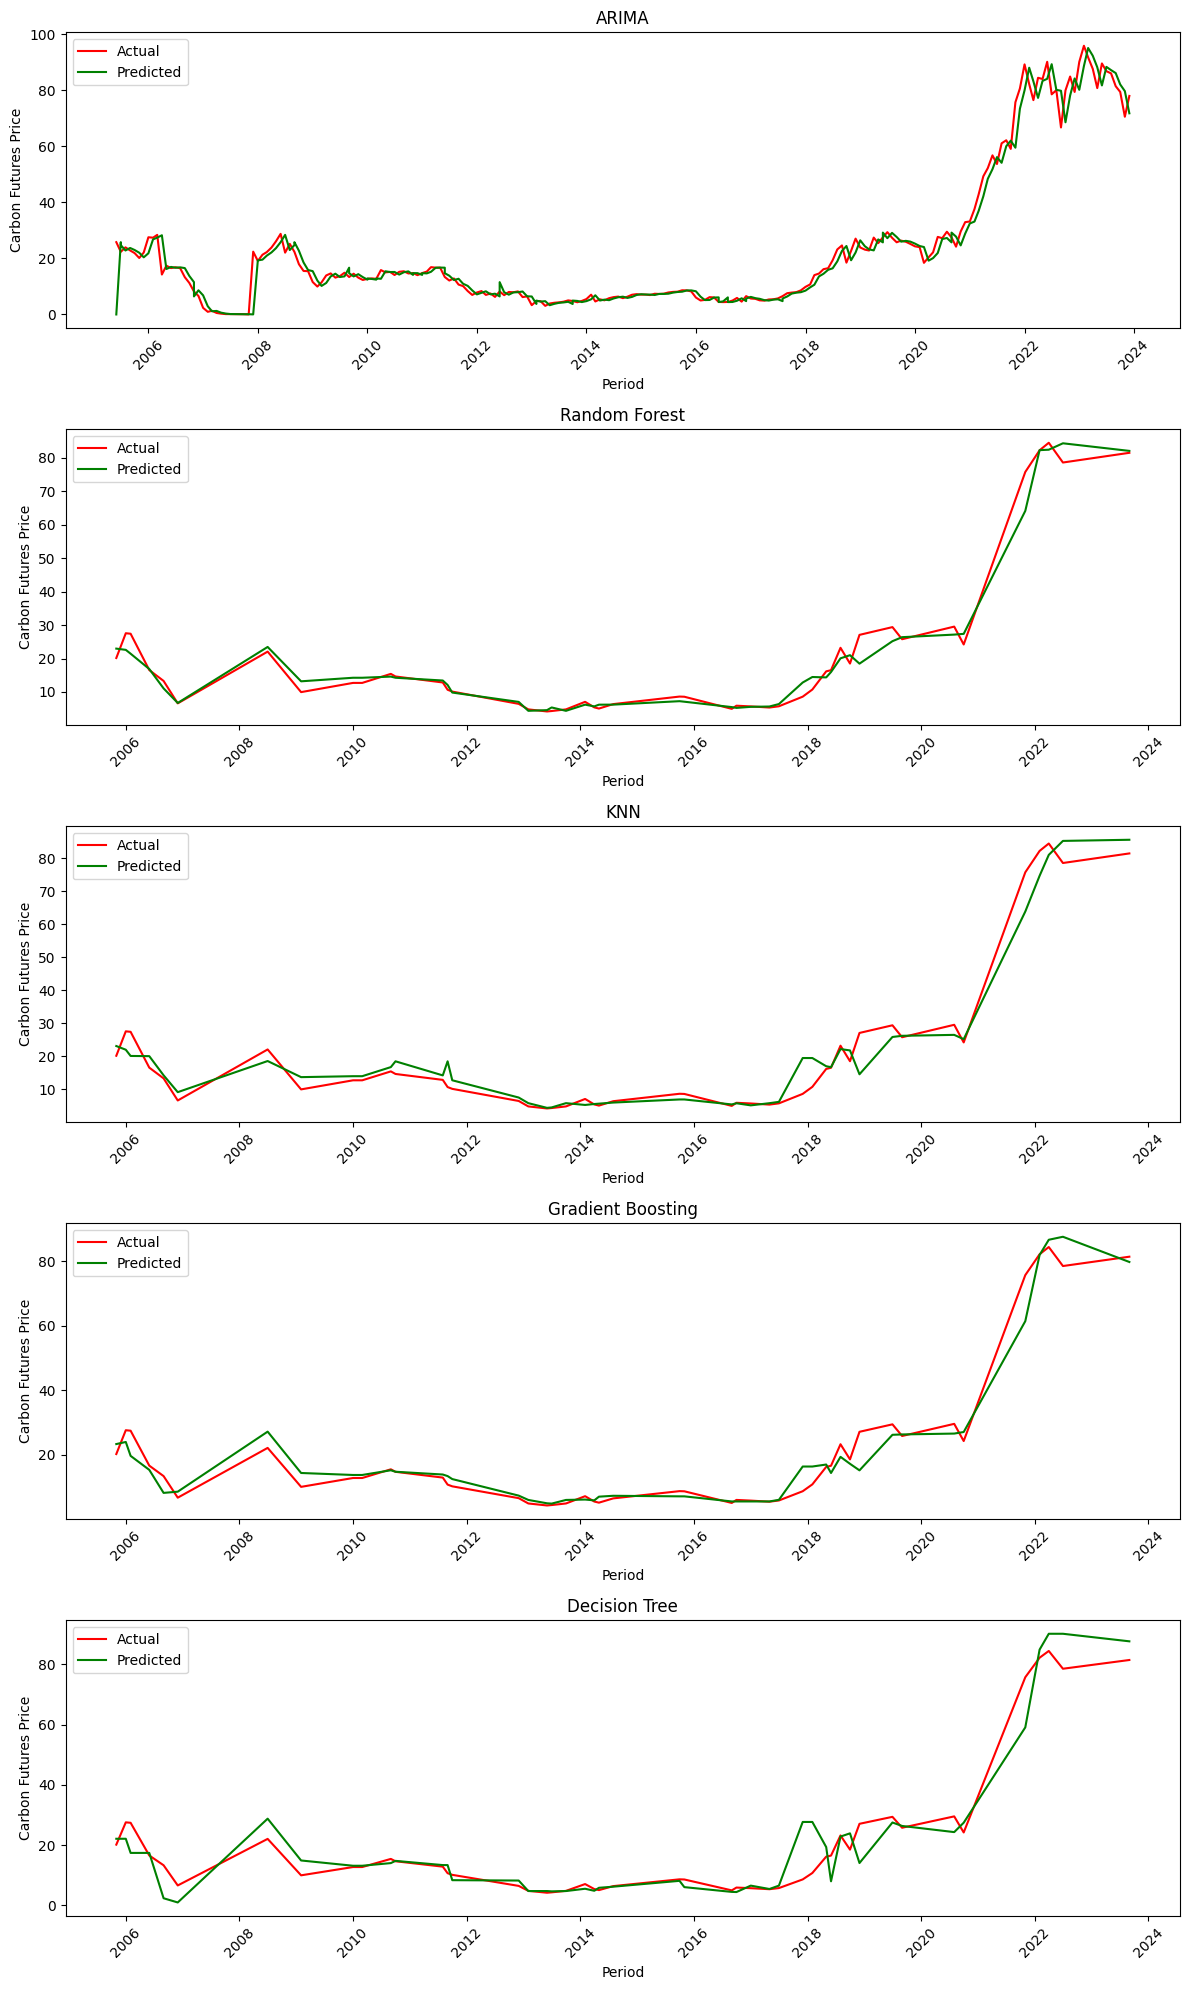

In [29]:
# Plotting the predicition vs actual values of target variable by models

fig, axs = plt.subplots(5, 1, figsize=(12, 20))

axs[0].plot(merged_df_arima.date, merged_df_arima.carbon_futures_price, label='Actual', color='red', linestyle='-')
axs[0].plot(merged_df_arima.date, merged_df_arima.arima_y_pred, label='Predicted', color='green', linestyle='-')
axs[0].set_xlabel('Period')
axs[0].set_ylabel('Carbon Futures Price')
axs[0].set_title('ARIMA')
axs[0].legend()
axs[0].tick_params(axis='x', rotation=45)

axs[1].plot(merged_df_rf.date, merged_df_rf.carbon_futures_price, label='Actual', color='red', linestyle='-')
axs[1].plot(merged_df_rf.date, merged_df_rf.rf_y_pred, label='Predicted', color='green', linestyle='-')
axs[1].set_xlabel('Period')
axs[1].set_ylabel('Carbon Futures Price')
axs[1].set_title('Random Forest')
axs[1].legend()
axs[1].tick_params(axis='x', rotation=45)

axs[2].plot(merged_df_knn.date, merged_df_knn.carbon_futures_price, label='Actual', color='red', linestyle='-')
axs[2].plot(merged_df_knn.date, merged_df_knn.knn_y_pred, label='Predicted', color='green', linestyle='-')
axs[2].set_xlabel('Period')
axs[2].set_ylabel('Carbon Futures Price')
axs[2].set_title('KNN')
axs[2].legend()
axs[2].tick_params(axis='x', rotation=45)

axs[3].plot(merged_df_gb.date, merged_df_gb.carbon_futures_price, label='Actual', color='red', linestyle='-')
axs[3].plot(merged_df_gb.date, merged_df_gb.gb_y_pred, label='Predicted', color='green', linestyle='-')
axs[3].set_xlabel('Period')
axs[3].set_ylabel('Carbon Futures Price')
axs[3].set_title('Gradient Boosting')
axs[3].legend()
axs[3].tick_params(axis='x', rotation=45)

axs[4].plot(merged_df_dt.date, merged_df_dt.carbon_futures_price, label='Actual', color='red', linestyle='-')
axs[4].plot(merged_df_dt.date, merged_df_dt.dt_y_pred, label='Predicted', color='green', linestyle='-')
axs[4].set_xlabel('Period')
axs[4].set_ylabel('Carbon Futures Price')
axs[4].set_title('Decision Tree')
axs[4].legend()
axs[4].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

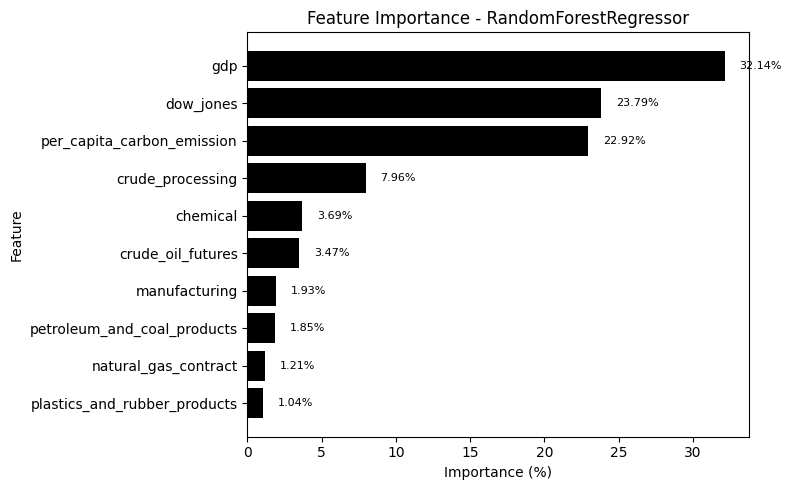

In [30]:
# Feature Importance

feature_importances = rf_model.feature_importances_
total_importance = sum(feature_importances)
percentage_importance = (feature_importances / total_importance) * 100
sorted_indices = np.argsort(percentage_importance)[::1]
sorted_importances = percentage_importance[sorted_indices]
sorted_features = np.array(X_train.columns)[sorted_indices]
plt.figure(figsize=(8, 5))
bars = plt.barh(range(len(sorted_importances)), sorted_importances, tick_label=sorted_features, color='black')
for bar, percentage in zip(bars, sorted_importances):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f'{percentage:.2f}%', ha='left', va='center', fontsize=8)
plt.xlabel('Importance (%)')
plt.ylabel('Feature')
plt.title(f'Feature Importance - {type(rf_model).__name__}')
plt.tight_layout()
plt.show()